<a href="https://colab.research.google.com/github/irembalcin/genomic-analysis/blob/main/wineveriseti.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import load_wine
import pandas as pd
wine = load_wine()
df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
df['target'] = wine.target
print(df.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

In [ ]:
X = wine.data
y = wine.target

X_df = pd.DataFrame(data=X, columns=wine.feature_names)
y_series = pd.Series(y, name='target')

print("--- X (Özellikler) Tablosunun İlk 5 Satırı ---")
print(X_df.head())

print("\n--- y (Hedef) Değişkeninin İlk 5 Değeri ---")
print(y_series.head())

--- X (Özellikler) Tablosunun İlk 5 Satırı ---
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_

In [ ]:
print("--- Doldurma İşlemi ÖNCESİ Eksik Değer Sayıları ---")
print(X_df.isnull().sum())
X_df = X_df.fillna(X_df.mean())
print("\n--- Doldurma İşlemi SONRASI Eksik Değer Sayıları ---")
print(X_df.isnull().sum())

--- Doldurma İşlemi ÖNCESİ Eksik Değer Sayıları ---
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

--- Doldurma İşlemi SONRASI Eksik Değer Sayıları ---
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                        

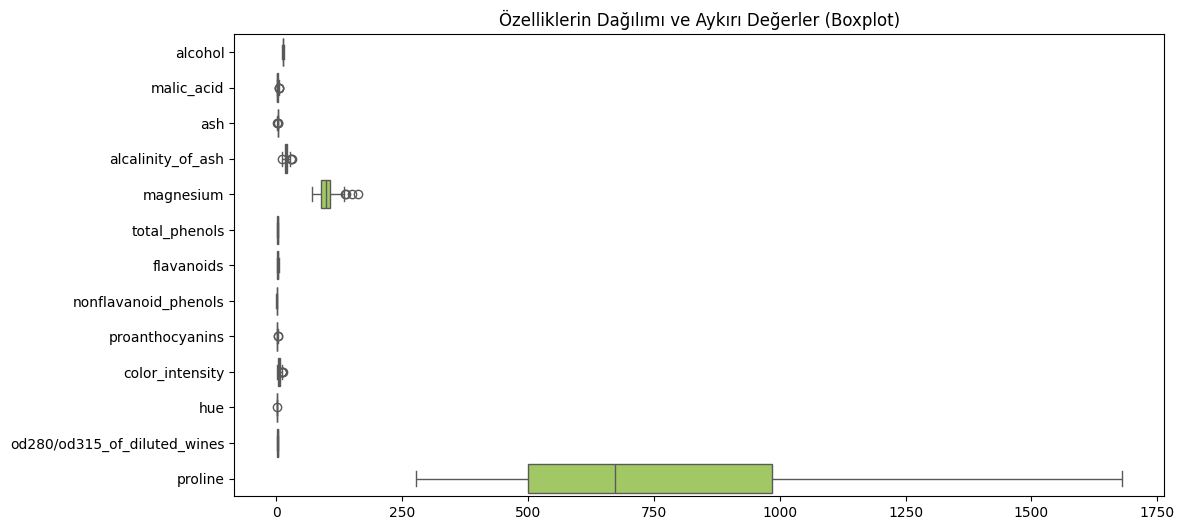

--- color_intensity Sütunu İçin Analiz ---
Alt Sınır: -1.25, Üst Sınır: 10.67
Tespit edilen aykırı değer sayısı: 4
Aykırı değer örnekleri:
151    10.80
158    13.00
159    11.75
166    10.68
Name: color_intensity, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(data=X_df, orient="h", palette="Set2")
plt.title("Özelliklerin Dağılımı ve Aykırı Değerler (Boxplot)")
plt.show()

column = 'color_intensity'
Q1 = X_df[column].quantile(0.25)
Q3 = X_df[column].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = X_df[(X_df[column] < lower_limit) | (X_df[column] > upper_limit)]

print(f"--- {column} Sütunu İçin Analiz ---")
print(f"Alt Sınır: {lower_limit:.2f}, Üst Sınır: {upper_limit:.2f}")
print(f"Tespit edilen aykırı değer sayısı: {len(outliers)}")

if len(outliers) > 0:
    print("Aykırı değer örnekleri:")
    print(outliers[column].head())

In [ ]:
print("--- Sütunların Veri Tipleri (dtypes) ---")
print(X_df.dtypes)

sayisal_degiskenler = X_df.select_dtypes(include=['float64', 'int64']).columns
sayisal_sayisi = len(sayisal_degiskenler)

kategorik_degiskenler = X_df.select_dtypes(include=['object', 'category', 'bool']).columns
kategorik_sayisi = len(kategorik_degiskenler)

print("\n--- Değişken Tipi Raporu ---")
print(f"Sayısal Değişken (Sütun) Sayısı: {sayisal_sayisi}")
print(f"Kategorik Değişken (Sütun) Sayısı: {kategorik_sayisi}")
print(f"Toplam Değişken Sayısı: {sayisal_sayisi + kategorik_sayisi}")

--- Sütunların Veri Tipleri (dtypes) ---
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
dtype: object

--- Değişken Tipi Raporu ---
Sayısal Değişken (Sütun) Sayısı: 13
Kategorik Değişken (Sütun) Sayısı: 0
Toplam Değişken Sayısı: 13


In [ ]:
istatistikler = X_df.describe()
ozet_tablo = istatistikler.loc[['mean', '50%', 'min', 'max', 'std', '25%', '75%']]

ozet_tablo.index = ['Mean', 'Median', 'Min', 'Max', 'Std', 'Q1', 'Q3']
sonuc_tablosu = ozet_tablo.T

print("--- Özelliklerin İstatistiksel Özeti ---")
print(sonuc_tablosu)

--- Özelliklerin İstatistiksel Özeti ---
                                    Mean   Median     Min      Max  \
alcohol                        13.000618   13.050   11.03    14.83   
malic_acid                      2.336348    1.865    0.74     5.80   
ash                             2.366517    2.360    1.36     3.23   
alcalinity_of_ash              19.494944   19.500   10.60    30.00   
magnesium                      99.741573   98.000   70.00   162.00   
total_phenols                   2.295112    2.355    0.98     3.88   
flavanoids                      2.029270    2.135    0.34     5.08   
nonflavanoid_phenols            0.361854    0.340    0.13     0.66   
proanthocyanins                 1.590899    1.555    0.41     3.58   
color_intensity                 5.058090    4.690    1.28    13.00   
hue                             0.957449    0.965    0.48     1.71   
od280/od315_of_diluted_wines    2.611685    2.780    1.27     4.00   
proline                       746.893258  673.500

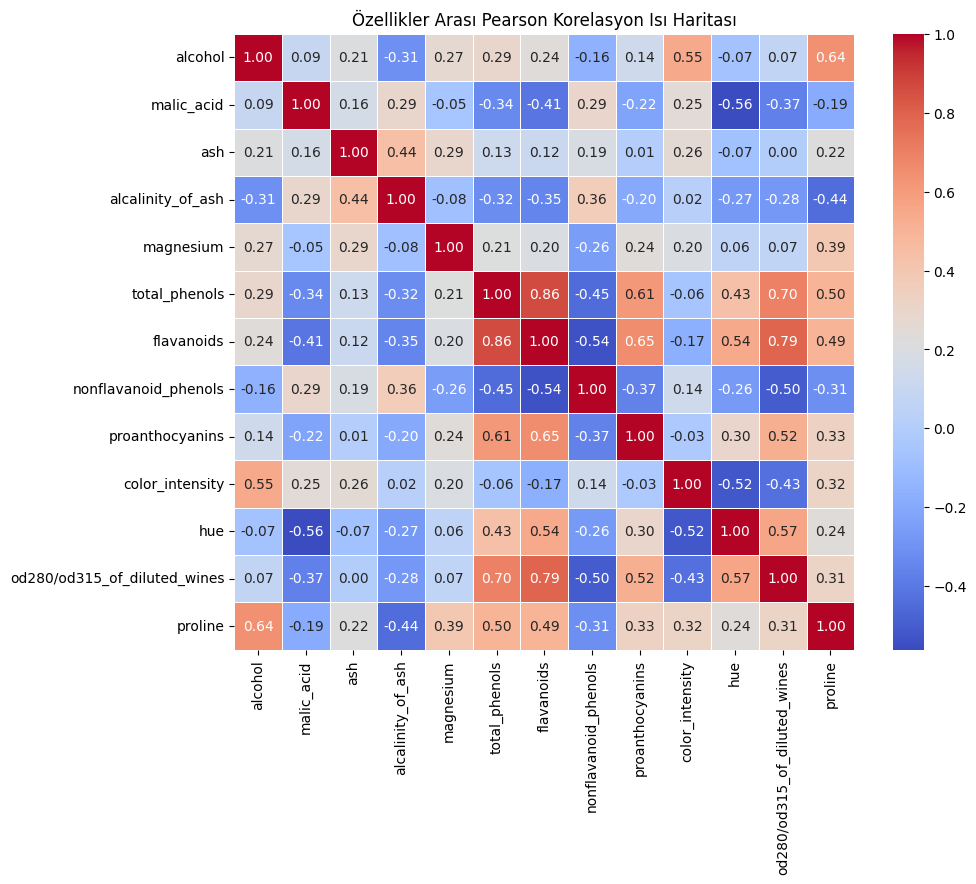

--- En Yüksek Korelasyonlu 3 Çift Özellik ---
flavanoids                    total_phenols    0.864564
od280/od315_of_diluted_wines  flavanoids       0.787194
                              total_phenols    0.699949
dtype: float64


In [ ]:
import numpy as np

corr_matrix = X_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Özellikler Arası Pearson Korelasyon Isı Haritası")
plt.show()

upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

top_3_pairs = upper_tri.unstack().sort_values(ascending=False).head(3)

print("--- En Yüksek Korelasyonlu 3 Çift Özellik ---")
print(top_3_pairs)

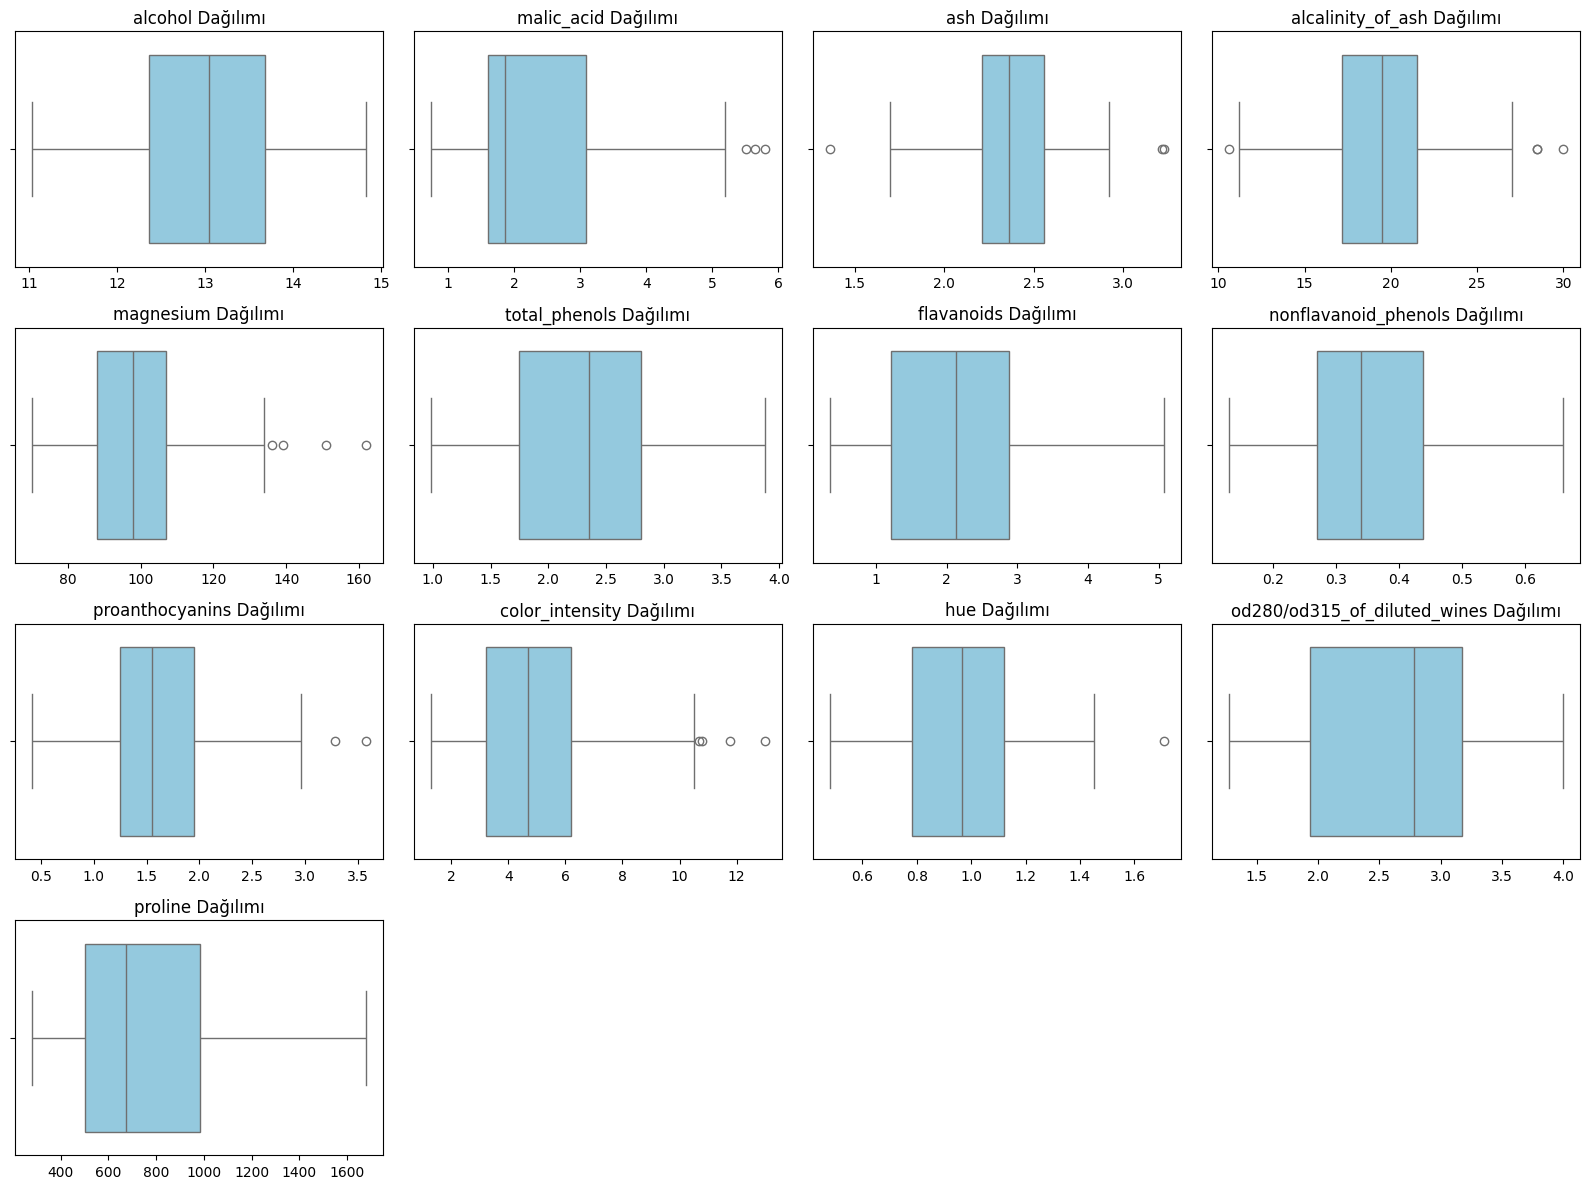

In [ ]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(X_df.columns):
    sns.boxplot(x=X_df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f"{col} Dağılımı")
    axes[i].set_xlabel('')
for j in range(13, 16):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled_array = scaler.fit_transform(X_df)
X_scaled = pd.DataFrame(X_scaled_array, columns=X_df.columns)

print("--- Ölçeklendirilmiş Veri (X_scaled) İlk 5 Satır ---")
print(X_scaled.head())

print("\n--- Ölçeklendirme Sonrası İstatistikler (Mean=0, Std=1) ---")
print(round(X_scaled.describe().loc[['mean', 'std']], 2))

--- Ölçeklendirilmiş Veri (X_scaled) İlk 5 Satır ---
    alcohol  malic_acid       ash  alcalinity_of_ash  magnesium  \
0  1.518613   -0.562250  0.232053          -1.169593   1.913905   
1  0.246290   -0.499413 -0.827996          -2.490847   0.018145   
2  0.196879    0.021231  1.109334          -0.268738   0.088358   
3  1.691550   -0.346811  0.487926          -0.809251   0.930918   
4  0.295700    0.227694  1.840403           0.451946   1.281985   

   total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
0       0.808997    1.034819             -0.659563         1.224884   
1       0.568648    0.733629             -0.820719        -0.544721   
2       0.808997    1.215533             -0.498407         2.135968   
3       2.491446    1.466525             -0.981875         1.032155   
4       0.808997    0.663351              0.226796         0.401404   

   color_intensity       hue  od280/od315_of_diluted_wines   proline  
0         0.251717  0.362177                  

In [ ]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp
)

print(f"Toplam Veri Sayısı: {len(X_scaled)}")
print(f"Eğitim Seti (Train)    : {len(X_train)} örnek (%70)")
print(f"Doğrulama Seti (Val)   : {len(X_val)} örnek (%10)")
print(f"Test Seti (Test)       : {len(X_test)} örnek (%20)")

print("\nVeri Boyutları:")
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

Toplam Veri Sayısı: 178
Eğitim Seti (Train)    : 124 örnek (%70)
Doğrulama Seti (Val)   : 18 örnek (%10)
Test Seti (Test)       : 36 örnek (%20)

Veri Boyutları:
X_train: (124, 13), X_val: (18, 13), X_test: (36, 13)


In [ ]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

print("1. Ham Veri Boyutu (Özellik Sayısı):", X_train.shape[1])

pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train)
X_val_pca   = pca.transform(X_val)
X_test_pca  = pca.transform(X_test)

print("2. PCA İndirgenmiş Veri Boyutu:", X_train_pca.shape[1])

lda = LinearDiscriminantAnalysis(n_components=2)

X_train_lda = lda.fit_transform(X_train, y_train)
X_val_lda   = lda.transform(X_val)
X_test_lda  = lda.transform(X_test)

print("3. LDA İndirgenmiş Veri Boyutu:", X_train_lda.shape[1])

print("\nPCA 2 Bileşen ile verinin yüzde kaçını açıklıyor?",
      round(sum(pca.explained_variance_ratio_) * 100, 2), "%")
print("LDA 2 Bileşen ile verinin yüzde kaçını açıklıyor?",
      round(sum(lda.explained_variance_ratio_) * 100, 2), "%")

1. Ham Veri Boyutu (Özellik Sayısı): 13
2. PCA İndirgenmiş Veri Boyutu: 2
3. LDA İndirgenmiş Veri Boyutu: 2

PCA 2 Bileşen ile verinin yüzde kaçını açıklıyor? 55.65 %
LDA 2 Bileşen ile verinin yüzde kaçını açıklıyor? 100.0 %


Tüm Bileşenlerin Açıklanan Varyans Ortalaması: 0.0769
Ortalamadan Büyük Olan (Seçilecek) Bileşen Sayısı: 3



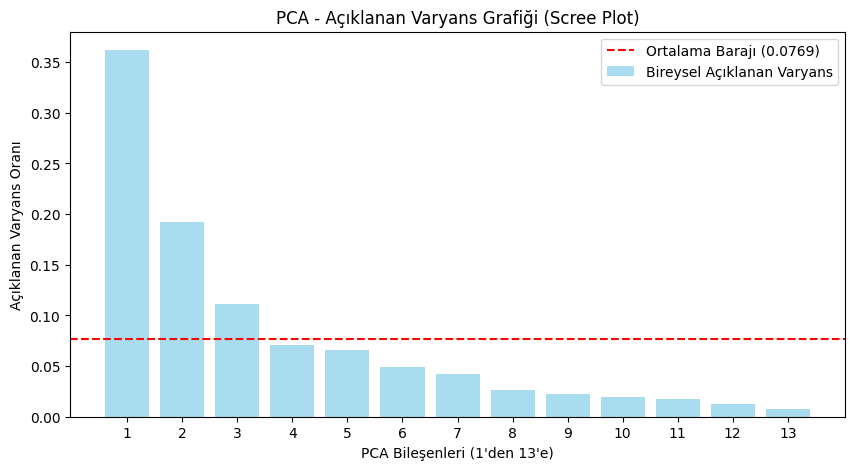

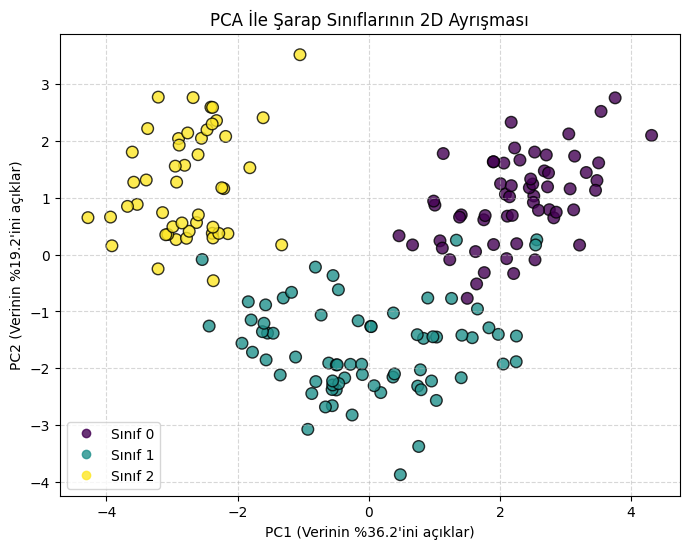

In [ ]:
pca_full = PCA()
pca_full.fit(X_scaled)

evr = pca_full.explained_variance_ratio_

mean_evr = np.mean(evr)

secilen_bilesen_sayisi = sum(evr > mean_evr)

print(f"Tüm Bileşenlerin Açıklanan Varyans Ortalaması: {mean_evr:.4f}")
print(f"Ortalamadan Büyük Olan (Seçilecek) Bileşen Sayısı: {secilen_bilesen_sayisi}\n")

plt.figure(figsize=(10, 5))

plt.bar(range(1, len(evr) + 1), evr, alpha=0.7, color='skyblue', label='Bireysel Açıklanan Varyans')

plt.axhline(y=mean_evr, color='red', linestyle='--', label=f'Ortalama Barajı ({mean_evr:.4f})')

plt.xlabel('PCA Bileşenleri (1\'den 13\'e)')
plt.ylabel('Açıklanan Varyans Oranı')
plt.title('PCA - Açıklanan Varyans Grafiği (Scree Plot)')
plt.xticks(range(1, len(evr) + 1))
plt.legend()
plt.show()

pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1], c=y, cmap='viridis', edgecolor='k', s=70, alpha=0.8)

plt.xlabel(f'PC1 (Verinin %{pca_2.explained_variance_ratio_[0]*100:.1f}\'ini açıklar)')
plt.ylabel(f'PC2 (Verinin %{pca_2.explained_variance_ratio_[1]*100:.1f}\'ini açıklar)')
plt.title('PCA İle Şarap Sınıflarının 2D Ayrışması')

plt.legend(handles=scatter.legend_elements()[0], labels=['Sınıf 0', 'Sınıf 1', 'Sınıf 2'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

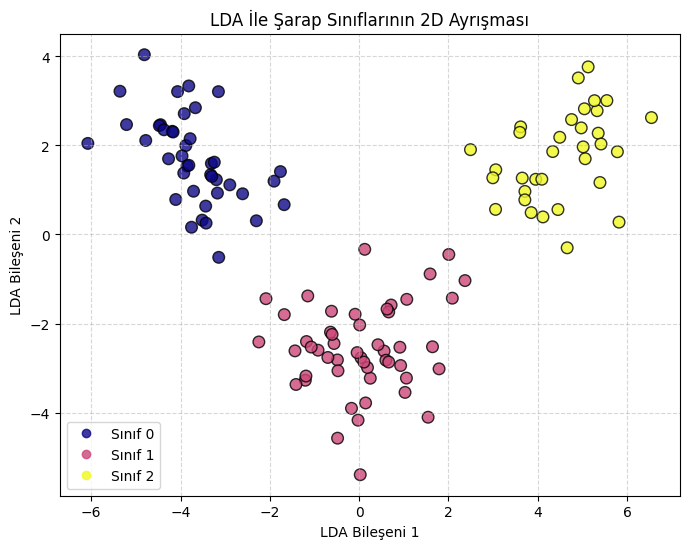

LDA 1. Bileşen Açıklama Oranı: %69.34
LDA 2. Bileşen Açıklama Oranı: %30.66


In [22]:
lda = LinearDiscriminantAnalysis(n_components=2)

X_train_lda = lda.fit_transform(X_train, y_train)

plt.figure(figsize=(8, 6))

scatter_lda = plt.scatter(X_train_lda[:, 0], X_train_lda[:, 1], c=y_train, cmap='plasma', edgecolor='k', s=70, alpha=0.8)

plt.xlabel('LDA Bileşeni 1')
plt.ylabel('LDA Bileşeni 2')
plt.title('LDA İle Şarap Sınıflarının 2D Ayrışması')

plt.legend(handles=scatter_lda.legend_elements()[0], labels=['Sınıf 0', 'Sınıf 1', 'Sınıf 2'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"LDA 1. Bileşen Açıklama Oranı: %{lda.explained_variance_ratio_[0]*100:.2f}")
print(f"LDA 2. Bileşen Açıklama Oranı: %{lda.explained_variance_ratio_[1]*100:.2f}")

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

veri_setleri = {
    "1. Ham Veri": (X_train, X_val),
    "2. PCA Verisi": (X_train_pca, X_val_pca),
    "3. LDA Verisi": (X_train_lda, X_val_lda)
}

modeller = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='mlogloss'),
    "Naive Bayes": GaussianNB()
}

sonuclar = []

for veri_adi, (X_tr, X_v) in veri_setleri.items():
    for model_adi, model in modeller.items():

        model.fit(X_tr, y_train)
        y_pred = model.predict(X_v)
        basari = accuracy_score(y_val, y_pred)

        sonuclar.append({
            "Veri Temsili": veri_adi,
            "Model": model_adi,
            "Validation Accuracy": basari
        })
df_sonuclar = pd.DataFrame(sonuclar)
pivot_tablo = df_sonuclar.pivot(index='Model', columns='Veri Temsili', values='Validation Accuracy')

print("--- 15 Modelin Validation Seti Başarı Oranları (Accuracy) ---")
print(pivot_tablo.map(lambda x: f"%{x*100:.2f}"))


--- 15 Modelin Validation Seti Başarı Oranları (Accuracy) ---
Veri Temsili        1. Ham Veri 2. PCA Verisi 3. LDA Verisi
Model                                                      
Decision Tree            %94.44        %88.89       %100.00
Logistic Regression     %100.00       %100.00       %100.00
Naive Bayes             %100.00       %100.00       %100.00
Random Forest           %100.00        %94.44       %100.00
XGBoost                 %100.00        %94.44       %100.00


In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

detayli_sonuclar = []

for veri_adi, (X_tr, X_v) in veri_setleri.items():
    for model_adi, model in modeller.items():

        model.fit(X_tr, y_train)

        y_pred = model.predict(X_v)

        y_proba = model.predict_proba(X_v)

        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, average='weighted')
        rec = recall_score(y_val, y_pred, average='weighted')
        f1 = f1_score(y_val, y_pred, average='weighted')

        roc_auc = roc_auc_score(y_val, y_proba, multi_class='ovr', average='weighted')

        detayli_sonuclar.append({
            "Veri Temsili": veri_adi,
            "Model": model_adi,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1,
            "ROC-AUC": roc_auc
        })

df_final_karsilastirma = pd.DataFrame(detayli_sonuclar)

df_final_karsilastirma = df_final_karsilastirma.sort_values(by="Accuracy", ascending=False)

print("--- 15 Modelin Tüm Metriklerle Karşılaştırmalı Performans Tablosu ---")
display(df_final_karsilastirma.style.highlight_max(axis=0, color='lightgreen'))

--- 15 Modelin Tüm Metriklerle Karşılaştırmalı Performans Tablosu ---


,Veri Temsili,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,1. Ham Veri,Logistic Regression,1.000000,1.000000,1.000000,1.000000,1.000000
2,1. Ham Veri,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
3,1. Ham Veri,XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000
5,2. PCA Verisi,Logistic Regression,1.000000,1.000000,1.000000,1.000000,1.000000
4,1. Ham Veri,Naive Bayes,1.000000,1.000000,1.000000,1.000000,1.000000
9,2. PCA Verisi,Naive Bayes,1.000000,1.000000,1.000000,1.000000,1.000000
10,3. LDA Verisi,Logistic Regression,1.000000,1.000000,1.000000,1.000000,1.000000
13,3. LDA Verisi,XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000
14,3. LDA Verisi,Naive Bayes,1.000000,1.000000,1.000000,1.000000,1.000000
12,3. LDA Verisi,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000


In [28]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

best_model = LogisticRegression(random_state=42, max_iter=1000)
best_model.fit(X_train, y_train)

y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)

report = classification_report(y_test, y_test_pred, output_dict=True)
roc_auc_final = roc_auc_score(y_test, y_test_proba, multi_class='ovr', average='weighted')

print("--- 9.1: Nihai Test Seti Performans Metrikleri ---")
print(f"Accuracy  : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision : {report['weighted avg']['precision']:.4f}")
print(f"Recall    : {report['weighted avg']['recall']:.4f}")
print(f"F1-score  : {report['weighted avg']['f1-score']:.4f}")
print(f"ROC-AUC   : {roc_auc_final:.4f}")

--- 9.1: Nihai Test Seti Performans Metrikleri ---
Accuracy  : 0.9722
Precision : 0.9741
Recall    : 0.9722
F1-score  : 0.9720
ROC-AUC   : 1.0000


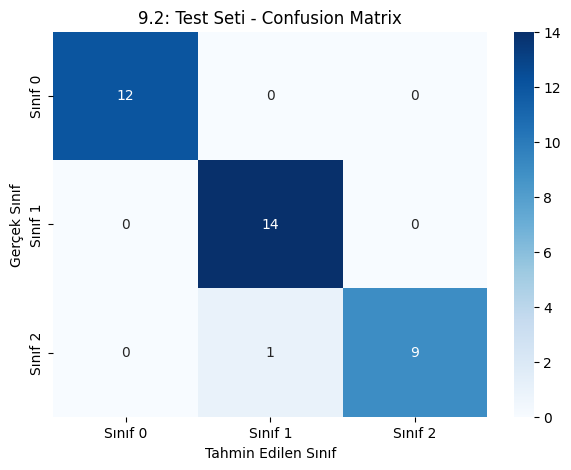

In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sınıf 0', 'Sınıf 1', 'Sınıf 2'],
            yticklabels=['Sınıf 0', 'Sınıf 1', 'Sınıf 2'])

plt.title('9.2: Test Seti - Confusion Matrix')
plt.xlabel('Tahmin Edilen Sınıf')
plt.ylabel('Gerçek Sınıf')
plt.show()

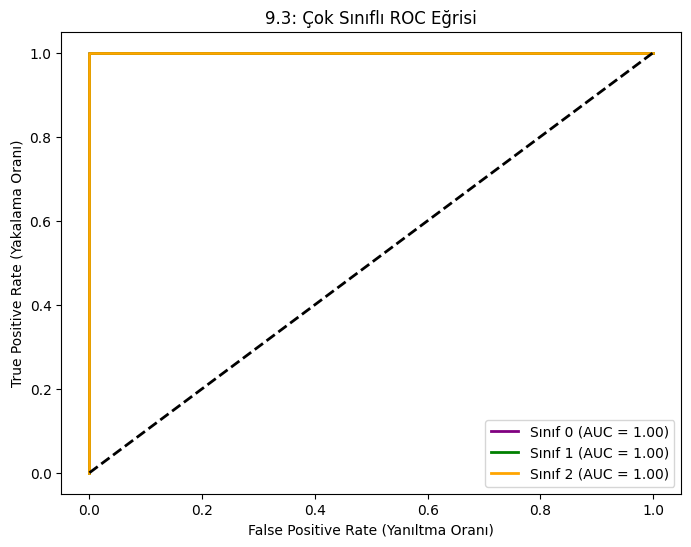

In [30]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = 3

plt.figure(figsize=(8, 6))
colors = ['purple', 'green', 'orange']

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'Sınıf {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate (Yanıltma Oranı)')
plt.ylabel('True Positive Rate (Yakalama Oranı)')
plt.title('9.3: Çok Sınıflı ROC Eğrisi')
plt.legend(loc="lower right")
plt.show()

--- SHAP Bar Plot (Özellik Önem Sıralaması) ---


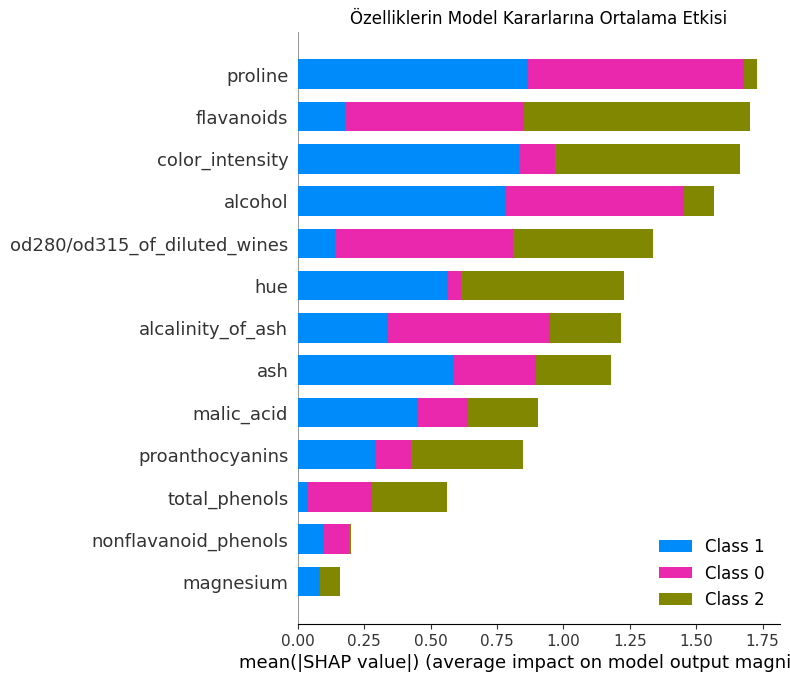


--- SHAP Summary Plot (Detaylı Analiz) ---


<Figure size 1000x600 with 0 Axes>

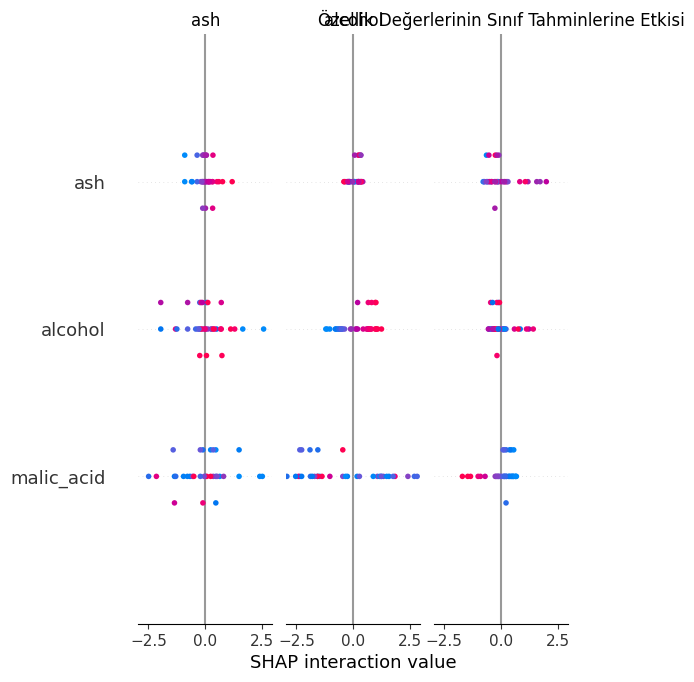

In [31]:
!pip install shap -q

import shap

explainer = shap.LinearExplainer(best_model, X_train)

shap_values = explainer.shap_values(X_test)

print("--- SHAP Bar Plot (Özellik Önem Sıralaması) ---")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", feature_names=X_df.columns, show=False)
plt.title("Özelliklerin Model Kararlarına Ortalama Etkisi")
plt.show()

print("\n--- SHAP Summary Plot (Detaylı Analiz) ---")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=X_df.columns, show=False)
plt.title("Özellik Değerlerinin Sınıf Tahminlerine Etkisi")
plt.show()

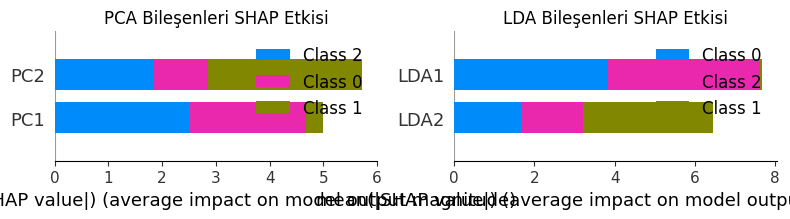

In [32]:
model_pca = modeller["Logistic Regression"].fit(X_train_pca, y_train)
explainer_pca = shap.LinearExplainer(model_pca, X_train_pca)
shap_values_pca = explainer_pca.shap_values(X_test_pca)

model_lda = modeller["Logistic Regression"].fit(X_train_lda, y_train)
explainer_lda = shap.LinearExplainer(model_lda, X_train_lda)
shap_values_lda = explainer_lda.shap_values(X_test_lda)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

plt.sca(ax1)
shap.summary_plot(shap_values_pca, X_test_pca, plot_type="bar",
                  feature_names=['PC1', 'PC2'], show=False)
ax1.set_title("PCA Bileşenleri SHAP Etkisi")

plt.sca(ax2)
shap.summary_plot(shap_values_lda, X_test_lda, plot_type="bar",
                  feature_names=['LDA1', 'LDA2'], show=False)
ax2.set_title("LDA Bileşenleri SHAP Etkisi")

plt.tight_layout()
plt.show()